In [1]:
#%pip install torch torchaudio transformers datasets accelerate


In [2]:
#%pip uninstall tensorflow tensorflow-cpu tensorflow-gpu tf-nightly -y


In [3]:
#%pip uninstall transformers -y
#%pip install transformers


In [4]:
#%pip uninstall torchcodec -y
#%pip install "datasets<2.18.0"

In [5]:
#%pip install -U transformers accelerate datasets


In [6]:
import torch
import numpy as np
from datasets import load_dataset, Audio, Value
from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.special import softmax
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

CONFIGURACIÓN

In [7]:
MODEL_NAME = "facebook/wav2vec2-base" # Nombre del modelo preentrenado
SAMPLING_RATE = 16000 # Frecuencia de muestreo - Tiene que ser 16k porque el modelo Wav2Vec2 fue entrenado con audios a esa frecuencia
NUM_LABELS = 2 # Nº de salidas del modelo
MAX_AUDIO_LEN = 10 * SAMPLING_RATE  # Duración del audio - 10 segundos

CARGA DEL DATASET

In [8]:
def cargar_carpeta(folder, label):
    data = []
    for fname in os.listdir(folder):
        if fname.endswith(".wav"):
            data.append({
                "path": os.path.join(folder, fname),
                "label": label
            })

    df = pd.DataFrame(data)
    return df

In [9]:
base = os.getcwd().rsplit("\\", 1)[0]
ruta_nat_español = 'Dataset\\Natural\\Español'
ruta_nat_ingles = 'Dataset\\Natural\\Inglés'
ruta_gen_español = 'Dataset\\Generado\\Español'
ruta_gen_ingles = 'Dataset\\Generado\\Inglés'

esp_nat = cargar_carpeta(os.path.join(base,ruta_nat_español),label=0)
ing_nat = cargar_carpeta(os.path.join(base,ruta_nat_ingles),label=0)
esp_gen = cargar_carpeta(os.path.join(base,ruta_gen_español),label=1)
ing_gen = cargar_carpeta(os.path.join(base,ruta_gen_ingles),label=1)

df = pd.concat([esp_nat, esp_gen, ing_nat, ing_gen], ignore_index=True)

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

In [10]:
train_df.to_csv(os.path.join(base,"mezclados//train.csv"), index=False)
val_df.to_csv(os.path.join(base,"mezclados//eval.csv"), index=False)
test_df.to_csv(os.path.join(base,"mezclados//test.csv"), index=False)

In [12]:
train_dataset = load_dataset( # Crea un dataset dividido en 2, train y eval
    "csv",
    data_files={
        "train": os.path.join(base,"mezclados//train.csv"),
        "eval": os.path.join(base,"mezclados//eval.csv")
    }
)

Generating train split: 0 examples [00:00, ? examples/s]

Generating eval split: 0 examples [00:00, ? examples/s]

In [13]:
train_dataset = train_dataset.cast_column( # Cambia la columna del path del audio para cargar el audio
    "path", Audio(sampling_rate=SAMPLING_RATE)
)

In [14]:
train_dataset = train_dataset.cast_column("label", Value("int64")) # Cambia el tipo de los labels a long

Casting the dataset:   0%|          | 0/160 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

FEATURE EXTRACTOR

Define como entra el audio al modelo. Wav2Vec2FeatureExtractor recibe el audio crudo, lo normaliza, lo paddea y lo convierte al formato que espera el modelo

In [15]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    MODEL_NAME, # Carga la configuración original del modelo
    sampling_rate=SAMPLING_RATE, # Fija la frecuencia de muestreo
    padding=True # El padding rellena con ceros los audios cortos y trunca los audios largos para que todos duren lo mismo
)

PREPROCESS FUNCTION

batch: audio cargado en el dataset

max_audio_len: Longitud máxima del audio

sampling_rate: Frecuencia de muestreo

feature_extractor: Feature extractor de Wav2Vec2

La función devuelve el nuevo audio tras aplicarle el feature extractor

In [16]:
from transformers import Wav2Vec2FeatureExtractor

def preprocess(batch, max_audio_len, sampling_rate, feature_extractor):
    audio = batch["path"]["array"] # Extraes el audio

    if len(audio) > max_audio_len: # Truncas el audio
        audio = audio[:max_audio_len]

    inputs = feature_extractor( # Devuelve los tensores de audio listos para el modelo
        audio,
        sampling_rate=sampling_rate,
        padding="max_length",
        max_length=max_audio_len,
        truncation=True
    )

    # Añadimos input_values
    batch["input_values"] = inputs["input_values"][0]

    return batch

# Aplicas la funcion a cada audio del dataset de entrenamiento
train_dataset = train_dataset.map(
    preprocess,
    fn_kwargs={
        "max_audio_len": MAX_AUDIO_LEN,
        "sampling_rate": SAMPLING_RATE,
        "feature_extractor": feature_extractor,
    },
    remove_columns=["path"],  # Quitas la columna path (ya no la necesitas ya que tienes input values)
    num_proc=4 # Procesamiento en paralelo para datasets grandes
)

Map (num_proc=4):   0%|          | 0/160 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/20 [00:00<?, ? examples/s]

In [17]:
print(train_dataset["train"][0].keys())

dict_keys(['label', 'input_values'])


MODEL

In [18]:
# Cargar modelo
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME, # Nombre del modelo que quieres cargar
    num_labels=NUM_LABELS, # Nº de salidas del modelo
    problem_type="single_label_classification" # Problema de clasificación binaria
)

# Congelar el feature extractor - Esto se hace para que los filtros del modelo no se sobreajusten
for param in model.wav2vec2.feature_extractor.parameters():
    param.requires_grad = False

# verificar qué se entrena
trainable = sum(p.requires_grad for p in model.parameters())
frozen = sum(not p.requires_grad for p in model.parameters())

print(f"Parámetros entrenables: {trainable}")
print(f"Parámetros congelados: {frozen}")


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parámetros entrenables: 206
Parámetros congelados: 9


METRICS

Saca las métricas de evaluación del modelo
- Precisión: verdaderos positivos / (verdaderos positivos + falsos positivos)
- Puntuación F1: Media armónica entre precisión y recall
- AUC: Mide que tan bien el modelo separa las clases real y fake 

In [19]:
def compute_metrics(pred):
    logits = pred.predictions
    labels = pred.label_ids

    probs = softmax(logits, axis=-1)
    p_fake = probs[:, 1]

    preds = (p_fake >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "auc": roc_auc_score(labels, p_fake) # Métrica que mide que tan bien se separa real de fake sin un umbral fijo
    }

TRAINING ARGS

Configuración para el entrenamiento del modelo

In [20]:
training_args = TrainingArguments(
    output_dir="./wav2vec2-deepfake", # Carpeta que guarda los checkpoints, logs y el mejor modelo
    eval_strategy="steps", # Evaluación cada x pasos
    save_strategy="steps", # Guardado cada x pasos
    logging_steps=50, # Cada 50 pasos calcula el loss, la tasa de aprendizaje y las métricas si toca evaluar
    save_steps=500, # Evalua cada 500 pasos
    eval_steps=500, # Guarda cada 500 pasos
    learning_rate=1e-5, # Tasa de aprendizaje
    per_device_train_batch_size=4,  
    per_device_eval_batch_size=4, 
    gradient_accumulation_steps=2, 
    num_train_epochs=5, # Épocas de entrenamiento
    fp16=True, 
    load_best_model_at_end=True, # Carga el modelo con mejor métrica auc
    metric_for_best_model="auc",
    report_to="none"
)

DATA_COLLATOR

Prepara los datos justo antes de entrar al modelo

In [21]:
def data_collator(features):
    input_values = [f["input_values"] for f in features] # Recoge todos los inputs values
    labels = [f["label"] for f in features] # Recoge todas las etiquetas

    return { # Devuelve un diccionario de los datos recogidos transformados a tensores de pyTorch
        "input_values": torch.tensor(input_values, dtype=torch.float32),
        "labels": torch.tensor(labels, dtype=torch.long),
    }


TRAINER

Ensambla todo el pipeline y define el entrenamiento.

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset["train"],
    eval_dataset=train_dataset["eval"],
    data_collator=data_collator,
    processing_class=feature_extractor,
    compute_metrics=compute_metrics
)

TRAIN

In [23]:
trainer.train()

Step,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=100, training_loss=1.0742892456054687, metrics={'train_runtime': 5082.9803, 'train_samples_per_second': 0.157, 'train_steps_per_second': 0.02, 'total_flos': 7.262906112e+16, 'train_loss': 1.0742892456054687, 'epoch': 5.0})

Guarda el modelo entrenado

In [24]:
trainer.save_model(os.path.join(base,"wav2vec2-deepfake-final"))
feature_extractor.save_pretrained(os.path.join(base,"wav2vec2-deepfake-final"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['c:\\Users\\ivire\\Documents\\GitHub\\TFG\\tfg-2526-xplicavoz\\wav2vec2-deepfake-final\\preprocessor_config.json']

Cargar modelo entrenado

In [25]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    os.path.join(base,"wav2vec2-deepfake-final")
)
model.eval()

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)


Usa el extractor de características del modelo entrenado

In [27]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    os.path.join(base,"wav2vec2-deepfake-final")
)

Carga del dataset de prueba

In [29]:
test_dataset = load_dataset(
    "csv",
    data_files={"test": os.path.join(base,"mezclados//test.csv")}
)["test"]


Generating test split: 0 examples [00:00, ? examples/s]

In [30]:
test_dataset = test_dataset.cast_column(
    "path",
    Audio(sampling_rate=16000)
)

Preprocesado del dataset de prueba - Igual que el de entrenamiento

In [31]:
SAMPLING_RATE = 16000
MAX_AUDIO_LEN = 10 * SAMPLING_RATE

def preprocess(batch, max_audio_len, sampling_rate, feature_extractor):
    audio = batch["path"]["array"]

    if len(audio) > max_audio_len:
        audio = audio[:max_audio_len]

    inputs = feature_extractor(
        audio,
        sampling_rate=sampling_rate,
        padding="max_length",
        max_length=max_audio_len,
        truncation=True
    )

    batch["input_values"] = inputs["input_values"][0]
    return batch


test_dataset = test_dataset.map(
    preprocess,
    fn_kwargs={
        "max_audio_len": MAX_AUDIO_LEN,
        "sampling_rate": SAMPLING_RATE,
        "feature_extractor": feature_extractor,
    },
    remove_columns=["path"],
    num_proc=2
)


Map (num_proc=2):   0%|          | 0/20 [00:00<?, ? examples/s]

Configuración del modelo para evaluación

In [32]:
eval_args = TrainingArguments(
    output_dir="./eval",
    per_device_eval_batch_size=4,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    processing_class=feature_extractor,
    compute_metrics=compute_metrics
)

Evaluación del modelo

In [33]:
metrics = trainer.evaluate()
metrics

{'eval_loss': 0.4544064998626709,
 'eval_model_preparation_time': 0.0151,
 'eval_accuracy': 0.85,
 'eval_f1': 0.8421052631578947,
 'eval_auc': 0.9,
 'eval_runtime': 82.2196,
 'eval_samples_per_second': 0.243,
 'eval_steps_per_second': 0.061}

In [34]:
predictions = trainer.predict(test_dataset)
predictions

PredictionOutput(predictions=array([[ 0.488297  , -0.4090159 ],
       [-0.6066334 ,  0.55098027],
       [ 0.40281454, -0.35867125],
       [ 0.1717613 , -0.10488439],
       [-0.6293437 ,  0.58276767],
       [ 0.43109742, -0.38540068],
       [ 0.5226032 , -0.45269406],
       [ 0.5375053 , -0.44898012],
       [-0.6150461 ,  0.58153445],
       [-0.4155657 ,  0.43377206],
       [ 0.48989633, -0.42339572],
       [ 0.42658105, -0.35360307],
       [-0.58818847,  0.5627058 ],
       [ 0.5040652 , -0.43968767],
       [ 0.3908073 , -0.3020991 ],
       [-0.34315827,  0.31382763],
       [-0.5690287 ,  0.5995614 ],
       [-0.61140674,  0.5413819 ],
       [ 0.3630311 , -0.29889837],
       [-0.5726375 ,  0.5336652 ]], dtype=float32), label_ids=array([0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1],
      dtype=int64), metrics={'test_loss': 0.4544064998626709, 'test_model_preparation_time': 0.0151, 'test_accuracy': 0.85, 'test_f1': 0.8421052631578947, 'test_auc': 0.9, 'tes

CLASIFICADOR FUZZY

In [35]:
import numpy as np

def fuzzy_membership(score, alpha=3.0):
    """
    score > 0 → fake
    score < 0 → real
    alpha controla la pendiente (incertidumbre)
    """
    return 1 / (1 + np.exp(-alpha * score))


In [36]:
def compute_scores(logits):
    """
    Convierte logits del modelo en scores reales/fake para fuzzy.
    """
    # Diferencia logits: l_fake - l_real
    scores = logits[:, 1] - logits[:, 0]
    return scores


In [37]:
from sklearn.metrics import roc_auc_score

def auc_from_scores(logits, labels, alpha=3.0):
    """
    Calcula AUC usando pertenencia fuzzy.
    """
    scores = compute_scores(logits)
    fuzzy_probs = fuzzy_membership(scores, alpha=alpha)
    auc = roc_auc_score(labels, fuzzy_probs)
    return auc


In [38]:
def tune_alpha(logits, labels, alpha_range=np.linspace(0.5, 10.0, 20)):
    """
    Devuelve alpha óptimo que maximiza AUC en validación.
    """
    best_alpha = alpha_range[0]
    best_auc = 0.0

    for alpha in alpha_range:
        auc = auc_from_scores(logits, labels, alpha=alpha)
        if auc > best_auc:
            best_auc = auc
            best_alpha = alpha

    return best_alpha, best_auc


In [39]:
# Predicciones sobre el set de validación
predictions = trainer.predict(test_dataset)
logits = predictions.predictions
labels = predictions.label_ids

In [40]:
# Ajustar alpha
best_alpha, best_auc = tune_alpha(logits, labels)
print(f"Alpha óptimo: {best_alpha:.2f}, AUC: {best_auc:.4f}")

# Obtener pertenencia fuzzy
scores = compute_scores(logits)
fuzzy_probs = fuzzy_membership(scores, alpha= 0.5)

Alpha óptimo: 0.50, AUC: 0.9000


In [41]:
fuzzy_probs

array([0.38968027, 0.6407928 , 0.40594774, 0.46547434, 0.64704055,
       0.39933202, 0.3804477 , 0.37912995, 0.64526504, 0.6045999 ,
       0.38778183, 0.40369517, 0.6400191 , 0.38417223, 0.41424274,
       0.58139265, 0.6420551 , 0.6402373 , 0.4180059 , 0.6348664 ],
      dtype=float32)

In [ ]:
def fuzzy_decision(score):
    if score < 0.5 and score >= 0.40:
        return "indeciso pero más real"
    elif score > 0.2 and score < 0.40:
        return "posiblemente real"
    elif score <= 0.2:
        return "real"
    elif score > 0.5 and score <= 0.60: 
        return "indeciso pero más IA"
    elif score > 0.60 and score < 0.8:
        return "posiblemente IA"
    elif score >= 0.8:
        return "IA"
    else:
        return "indeterminado"

In [43]:
pred_fuzzy = [fuzzy_decision(m) for m in fuzzy_probs]

In [44]:
import pandas as pd

df = pd.DataFrame({
    "audio_id": range(len(fuzzy_probs)),
    "score": fuzzy_probs,
    "decision_fuzzy": pred_fuzzy,
    "label_real": predictions.label_ids
})

df

,audio_id,score,decision_fuzzy,label_real
0,0,0.389680,posiblemente real,0
1,1,0.640793,posiblemente IA,1
2,2,0.405948,indeciso pero más real,0
3,3,0.465474,indeciso pero más real,0
4,4,0.647041,posiblemente IA,1
5,5,0.399332,posiblemente real,1
6,6,0.380448,posiblemente real,0
7,7,0.379130,posiblemente real,0
8,8,0.645265,posiblemente IA,1
9,9,0.604600,posiblemente IA,1


Falla en 
c:\Users\ivire\Desktop\TFG\Investigacion\Datasets//Nuestro//Natural//Inglés\I_3_N.wav,0
c:\Users\ivire\Desktop\TFG\Investigacion\Datasets//Nuestro//Natural//Inglés\I_11_N.wav,0



Explicación de por que un audio real lo clasifica como que seguro es ia y viceversa

In [45]:
test_dataset

Dataset({
    features: ['label', 'input_values'],
    num_rows: 20
})

XAI para las características

In [46]:
def explain_audio(model, input_values, target_class, baseline=None, steps=50):
    """
    Compute Integrated Gradients for audio input.
    
    Args:
        model: modelo HF (ej. Wav2Vec2)
        input_values: tensor 1D (audio)
        target_class: índice de la clase a explicar
        baseline: tensor base (default = ceros)
        steps: número de pasos para la aproximación de la integral
    
    Returns:
        numpy array con las atribuciones
    """

    model.eval()

    device = next(model.parameters()).device
    input_values = input_values.to(device)

    if baseline is None:
        baseline = torch.zeros_like(input_values).to(device)

    # Escalado entre baseline y input
    scaled_inputs = [
        baseline + (float(i) / steps) * (input_values - baseline)
        for i in range(1, steps + 1)
    ]

    grads = []

    for scaled_input in scaled_inputs:
        scaled_input = scaled_input.unsqueeze(0).requires_grad_(True)

        outputs = model(input_values=scaled_input)
        logit = outputs.logits[0, target_class]

        model.zero_grad()
        logit.backward()

        grads.append(scaled_input.grad.detach())

    # Promedio de gradientes
    avg_grads = torch.mean(torch.stack(grads), dim=0)

    # Integrated gradients
    integrated_grads = (input_values - baseline) * avg_grads.squeeze(0)

    return integrated_grads.detach().cpu().numpy()


In [49]:
audio1 = torch.tensor(test_dataset[19]["input_values"])
attr1 = explain_audio(model, audio1, target_class=0)  # AUDIO QUE FALLA 

EJE X - Tiempo en milisegundos

EJE Y - Atribución -> 
- Target class = 1 - Valor positivo: Favorece predicción hacia generado. Valor negativo: Favorece predicción hacia real
- Target class = 0 - Valor positivo: Favorece predicción hacia real. Valor negativo: Favorece predicción hacia generado

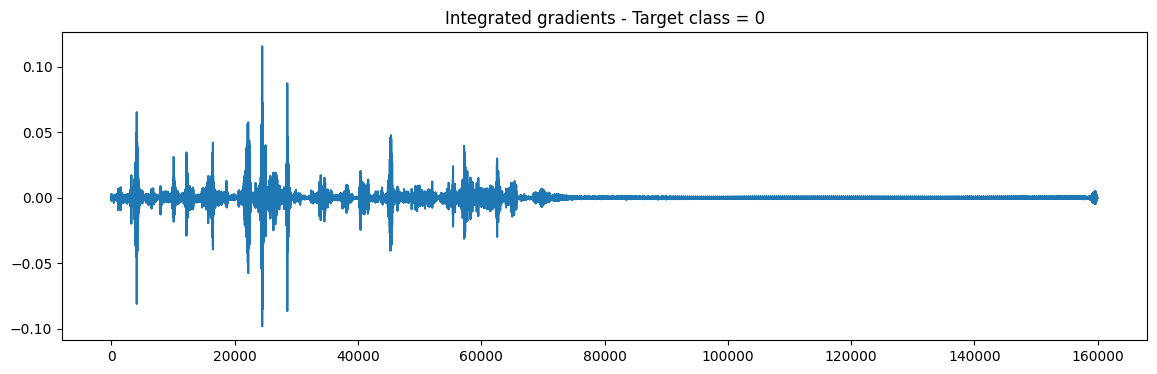

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(attr1)
plt.title("Integrated gradients - Target class = 0")
plt.show()

In [51]:
audio2 = torch.tensor(test_dataset[4]["input_values"])
attr2 = explain_audio(model,audio2,target_class=0) # AUDIO QUE ACIERTA

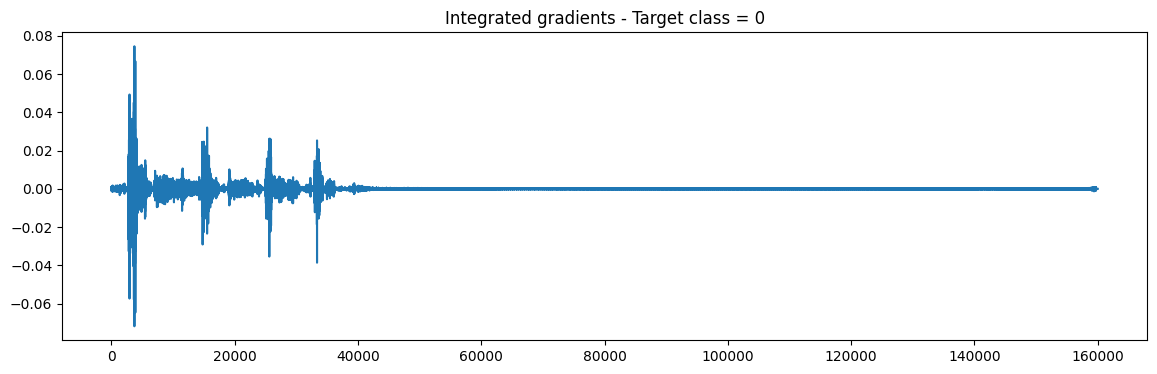

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(attr2)
plt.title("Integrated gradients - Target class = 0")
plt.show()

IA EXPLICABLE (Sin acabar)

In [53]:
import os
import librosa
import numpy as np
import pandas as pd
import parselmouth
from scipy.stats import skew, kurtosis
from tqdm import tqdm
import json

In [54]:
datos_con_caracteristicas = "data//test.csv"
test_out = "test_out.csv"

In [55]:
def get_files(dir):
    all_audio_files = []
    for root, _, files in os.walk(dir):
        for file in files:
            if file.lower().endswith(".wav"):
                all_audio_files.append(os.path.join(root, file))
    return all_audio_files

In [56]:
test_files = get_files(datos_con_caracteristicas)

In [57]:
print(test_files)

[]


In [58]:
def extract_pitch(audio, sr):
    f0, voiced_flag, voiced_prob = librosa.pyin(
            y=audio, 
            fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'),
            sr=sr
        )

    f0_sonoro = f0[voiced_flag]
    
    if len(f0_sonoro) == 0:
        return None  # No hay pitch detectable

    return f0_sonoro

def extract_formants(path):
    snd = parselmouth.Sound(path)
    formant = snd.to_formant_burg()
    f1, f2, f3 = [], [], []
    for t in np.linspace(0, snd.duration, 100):
        try:
            f1.append(formant.get_value_at_time(1, t))
            f2.append(formant.get_value_at_time(2, t))
            f3.append(formant.get_value_at_time(3, t))
        except:
            pass
    return f1, f2, f3

def extract_silence(audio, sr, threshold=0.02):
    energy = librosa.feature.rms(y=audio)[0]
    silence_ratio = np.mean(energy < threshold)
    return silence_ratio

def extract_hnr(path):
    snd = parselmouth.Sound(path)
    hnr = snd.to_harmonicity()
    return np.mean(hnr.values[hnr.values != -200])

In [59]:
def extract_features(path):
    try:
        audio, sr = librosa.load(path, sr=None)
        duration = librosa.get_duration(y=audio, sr=sr)
        
        rms = np.mean(librosa.feature.rms(y=audio))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))
        centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
        bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))
        flatness = np.mean(librosa.feature.spectral_flatness(y=audio))
        
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

        pitch = extract_pitch(audio, sr)
        pitch_mean = np.nanmean(pitch)
        pitch_std = np.nanstd(pitch)
        
        f1, f2, f3 = extract_formants(path)
        f1_mean = np.nanmean(f1)
        f2_mean = np.nanmean(f2)
        f3_mean = np.nanmean(f3)
        
        hnr = extract_hnr(path)
        silence = extract_silence(audio, sr)
        
        features = {
            "filename": path,
            "duration": duration,
            "rms": rms,
            "zcr": zcr,
            "spectral_centroid": centroid,
            "spectral_bandwidth": bandwidth,
            "spectral_rolloff": rolloff,
            "spectral_flatness": flatness,
            "pitch": pitch,
            "pitch_mean": pitch_mean,
            "pitch_std": pitch_std,
            "f1": f1,
            "f2": f2,
            "f3": f3,
            "f1_mean": f1_mean,
            "f2_mean": f2_mean,
            "f3_mean": f3_mean,
            "hnr": hnr,
            "silence_ratio": silence,
        }

        for i, val in enumerate(mfcc):
            features[f"mfcc_{i+1}"] = val
            features[f"mfcc_{i+1}_mean"] = np.nanmean(val)
        
        # Estadísticos globales
        features["skewness"] = skew(audio)
        features["kurtosis"] = kurtosis(audio)
        
        return features
    except Exception as e:
        print(f"Error procesando {path}: {e}")
        return None

In [60]:
def features(files):
    features_list = []
    for file in tqdm(files, desc="Extrayendo características"):
        feats = extract_features(file)
        if feats:
            features_list.append(feats)
    return features_list

In [61]:
df_test = pd.DataFrame(features(test_files))

Extrayendo características: 0it [00:00, ?it/s]


In [62]:
print(df_test)

Empty DataFrame
Columns: []
Index: []


In [63]:
df_test['label'] = 0
df_test['pitch'] = df_test['pitch'].apply(lambda x: json.dumps(x.tolist()))
df_test['f1'] = df_test['f1'].apply(lambda x: json.dumps(x))
df_test['f2'] = df_test['f2'].apply(lambda x: json.dumps(x))
df_test['f3'] = df_test['f3'].apply(lambda x: json.dumps(x))
for col in df_test.columns:
    if 'mfcc' in col and not col.endswith('mean'):
        df_test[col] = df_test[col].apply(lambda x: json.dumps(x.tolist()))

KeyError: 'pitch'

In [ ]:
df_test.to_csv(test_out, index=False)

In [ ]:
df_test = pd.read_csv(test_out)

In [ ]:
df['pitch'] = df['pitch'].apply(lambda x: np.array(json.loads(x)))
df['f1'] = df['f1'].apply(lambda x: json.loads(x))
df['f2'] = df['f2'].apply(lambda x: json.loads(x))
df['f3'] = df['f3'].apply(lambda x: json.loads(x))
for col in df.columns:
    if 'mfcc' in col and not col.endswith('mean'):
        df[col] = df[col].apply(lambda x: np.array(json.loads(x)))